Digits dataset loaded.
Training samples: 1437, Test samples: 360

========== RANDOM FOREST ==========
Best RF Params: {'max_depth': 10, 'n_estimators': 200}
RF Accuracy: 0.9722222222222222

========== ADABOOST ==========
Best Ada Params: {'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost Accuracy: 0.8638888888888889


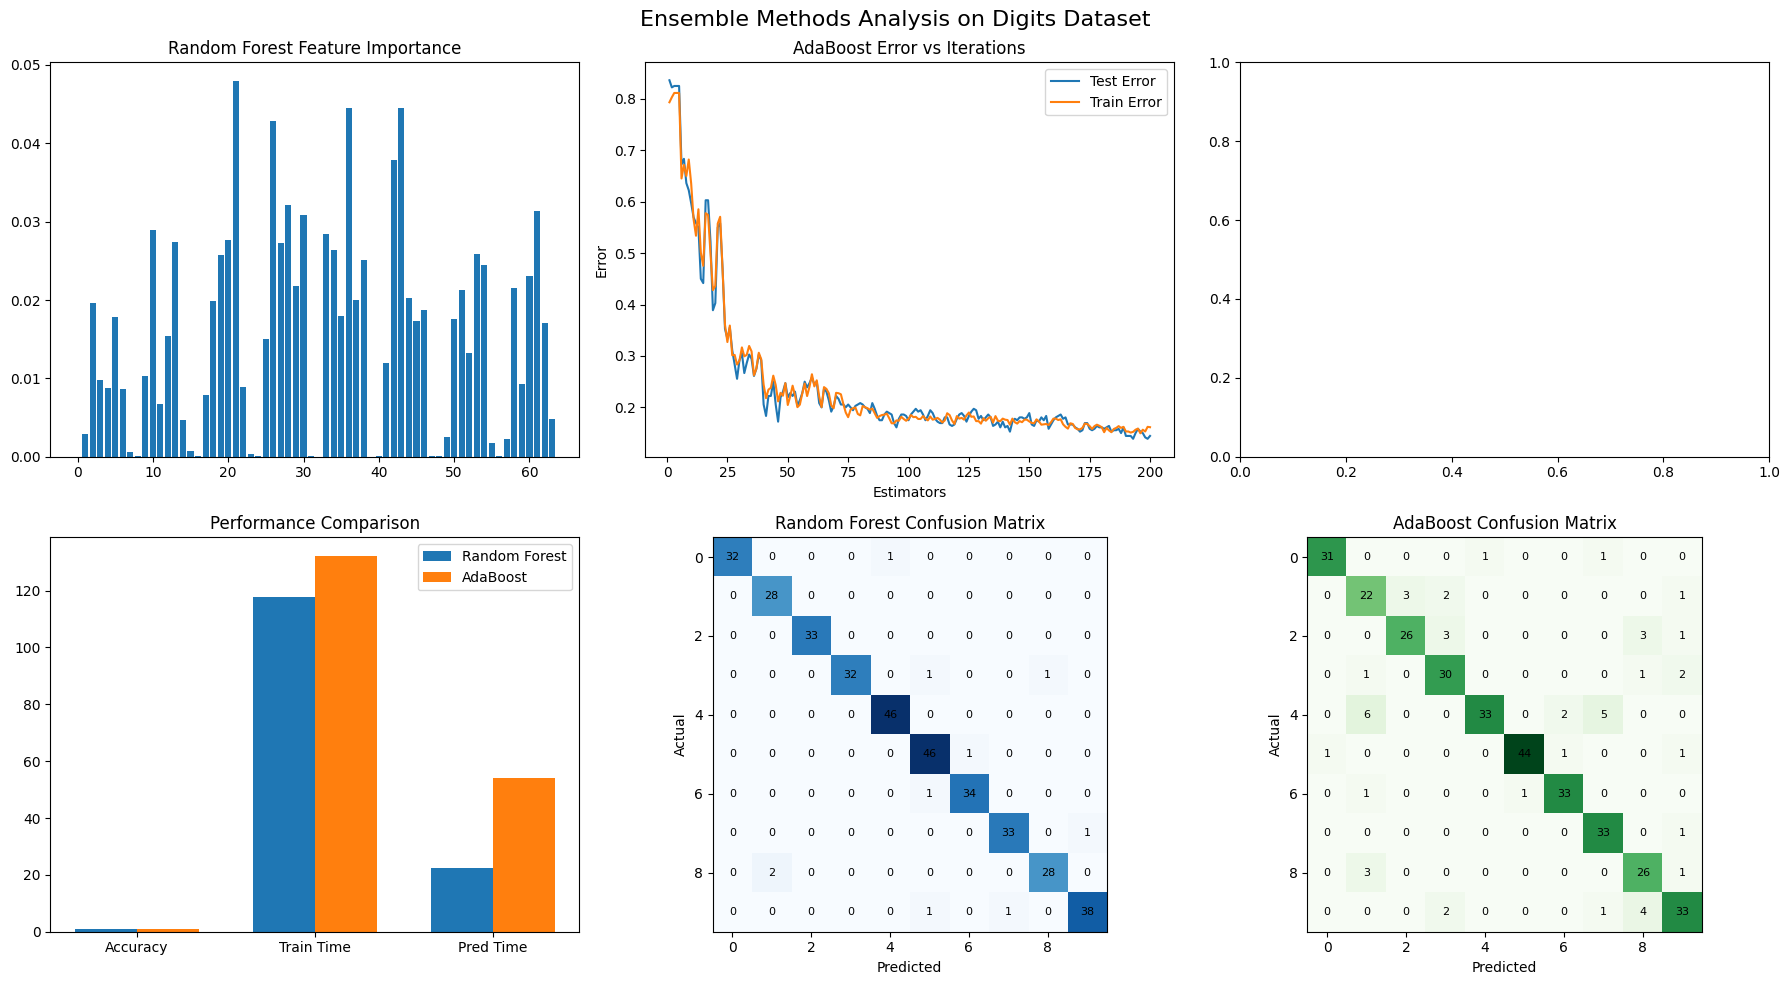


MODEL COMPARISON
Metric                   Random Forest       AdaBoost            
------------------------------------------------------------
Accuracy                 0.9722              0.8639              
Training Time (s)        1.177               1.321               
Prediction Time (ms)     22.54               54.05               
OOB/Test Error           0.0278              0.1361              
Best n_estimators        200                 200                 
------------------------------------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import time
import warnings

warnings.filterwarnings('ignore')

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Digits dataset loaded.")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# ====================================================
# PART A : RANDOM FOREST
# ====================================================

print("\n========== RANDOM FOREST ==========")

rf_params = {
    'n_estimators': [50,100,200],
    'max_depth': [10,20,None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42),
    rf_params,
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

# Training time
start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

# Prediction time
start = time.time()
y_pred_rf = rf.predict(X_test)
rf_pred_time = time.time() - start

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Best RF Params:", rf_grid.best_params_)
print("RF Accuracy:", rf_accuracy)

# Feature importance plot
importances = rf.feature_importances_
axes[0,0].bar(range(len(importances)), importances)
axes[0,0].set_title("Random Forest Feature Importance")

# ====================================================
# PART B : ADABOOST
# ====================================================

print("\n========== ADABOOST ==========")

base_dt = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_params = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.1,0.5,1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_dt, random_state=42),
    ada_params,
    cv=3,
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)
ada = ada_grid.best_estimator_

# Training time
start = time.time()
ada.fit(X_train, y_train)
ada_train_time = time.time() - start

# Prediction time
start = time.time()
y_pred_ada = ada.predict(X_test)
ada_pred_time = time.time() - start

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("Best Ada Params:", ada_grid.best_params_)
print("AdaBoost Accuracy:", ada_accuracy)

# ====================================================
# AdaBoost Error vs Iterations
# ====================================================

test_errors = []
train_errors = []

ada_temp = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_temp.fit(X_train, y_train)

for pred in ada_temp.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, pred))

for pred in ada_temp.staged_predict(X_train):
    train_errors.append(1 - accuracy_score(y_train, pred))

axes[0,1].plot(range(1,201), test_errors, label="Test Error")
axes[0,1].plot(range(1,201), train_errors, label="Train Error")
axes[0,1].set_title("AdaBoost Error vs Iterations")
axes[0,1].set_xlabel("Estimators")
axes[0,1].set_ylabel("Error")
axes[0,1].legend()

# ====================================================
# Performance Comparison
# ====================================================

metrics = ['Accuracy','Train Time','Pred Time']

rf_vals = [rf_accuracy, rf_train_time*100, rf_pred_time*1000]
ada_vals = [ada_accuracy, ada_train_time*100, ada_pred_time*1000]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1,0].bar(x-width/2, rf_vals, width, label="Random Forest")
bars2 = axes[1,0].bar(x+width/2, ada_vals, width, label="AdaBoost")

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(metrics)
axes[1,0].set_title("Performance Comparison")
axes[1,0].legend()

# ====================================================
# RF Confusion Matrix
# ====================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

im1 = axes[1,1].imshow(cm_rf, cmap='Blues')
axes[1,1].set_title("Random Forest Confusion Matrix")
axes[1,1].set_xlabel("Predicted")
axes[1,1].set_ylabel("Actual")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        axes[1,1].text(j,i,cm_rf[i,j],
                       ha='center',va='center',fontsize=8)

# ====================================================
# AdaBoost Confusion Matrix
# ====================================================

cm_ada = confusion_matrix(y_test, y_pred_ada)

im2 = axes[1,2].imshow(cm_ada, cmap='Greens')
axes[1,2].set_title("AdaBoost Confusion Matrix")
axes[1,2].set_xlabel("Predicted")
axes[1,2].set_ylabel("Actual")

for i in range(cm_ada.shape[0]):
    for j in range(cm_ada.shape[1]):
        axes[1,2].text(j,i,cm_ada[i,j],
                       ha='center',va='center',fontsize=8)

# ====================================================
# Final Plot
# ====================================================

plt.suptitle("Ensemble Methods Analysis on Digits Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# ====================================================
# Comparison Table
# ====================================================

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(f"{'Metric':<25}{'Random Forest':<20}{'AdaBoost':<20}")
print("-"*60)

print(f"{'Accuracy':<25}{rf_accuracy:<20.4f}{ada_accuracy:<20.4f}")
print(f"{'Training Time (s)':<25}{rf_train_time:<20.3f}{ada_train_time:<20.3f}")
print(f"{'Prediction Time (ms)':<25}{rf_pred_time*1000:<20.2f}{ada_pred_time*1000:<20.2f}")
print(f"{'OOB/Test Error':<25}{1-rf.oob_score_:<20.4f}{1-ada_accuracy:<20.4f}")
print(f"{'Best n_estimators':<25}{rf.n_estimators:<20}{ada.n_estimators:<20}")

print("-"*60)


PART C: GRADIENT BOOSTING
Gradient Boosting Accuracy: 0.9694
Training Time: 10.582s
Prediction Time: 9.72 ms

PART D: STACKING ENSEMBLE
Stacking Accuracy: 0.9833

PART E: RANDOMIZED SEARCH
Best Parameters (RandomizedSearch): {'n_estimators': np.int64(200), 'min_samples_split': 2, 'max_depth': 20}

PART F: BOOTSTRAP ANALYSIS
Accuracy with Bootstrap: 0.9722222222222222
Accuracy without Bootstrap: 0.9777777777777777

PART G: FEATURE IMPORTANCE COMPARISON


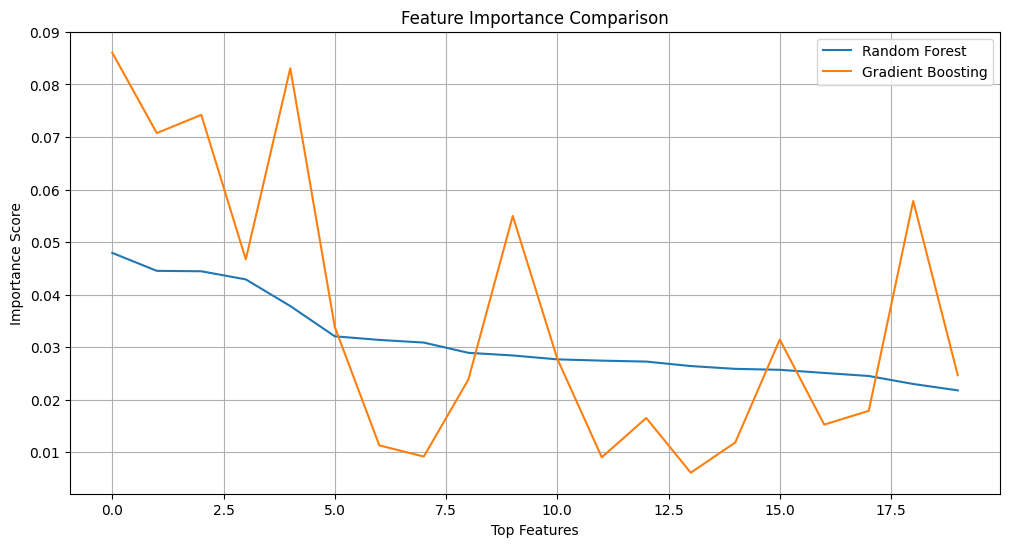


FINAL MODEL COMPARISON
Model                Accuracy       
----------------------------------------
Random Forest        0.9722         
AdaBoost             0.8639         
Gradient Boosting    0.9694         
Stacking             0.9833         
----------------------------------------


In [7]:
#POST LAB

from sklearn.ensemble import GradientBoostingClassifier

print("\n" + "="*50 + "\nPART C: GRADIENT BOOSTING\n" + "="*50)

gb = GradientBoostingClassifier(random_state=42)

start_time = time.time()
gb.fit(X_train, y_train)
gb_train_time = time.time() - start_time

start_time = time.time()
y_pred_gb = gb.predict(X_test)
gb_pred_time = time.time() - start_time

gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print(f"Training Time: {gb_train_time:.3f}s")
print(f"Prediction Time: {gb_pred_time*1000:.2f} ms")


# ====================================================
# PART D: STACKING ENSEMBLE
# ====================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

print("\n" + "="*50 + "\nPART D: STACKING ENSEMBLE\n" + "="*50)

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, kernel='rbf')),
    ('dt', DecisionTreeClassifier(max_depth=5))
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression()
)

start_time = time.time()
stack_model.fit(X_train, y_train)
stack_train_time = time.time() - start_time

start_time = time.time()
y_pred_stack = stack_model.predict(X_test)
stack_pred_time = time.time() - start_time

stack_accuracy = accuracy_score(y_test, y_pred_stack)

print(f"Stacking Accuracy: {stack_accuracy:.4f}")


# ====================================================
# PART E: RANDOMIZED SEARCH CV
# ====================================================

from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*50 + "\nPART E: RANDOMIZED SEARCH\n" + "="*50)

param_dist = {
    'n_estimators': np.arange(50,300,50),
    'max_depth': [None,10,20,30],
    'min_samples_split': [2,5,10]
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)

print("Best Parameters (RandomizedSearch):", rand_search.best_params_)


# ====================================================
# PART F: BOOTSTRAP EFFECT IN RANDOM FOREST
# ====================================================

print("\n" + "="*50 + "\nPART F: BOOTSTRAP ANALYSIS\n" + "="*50)

rf_bootstrap = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    random_state=42
)

rf_no_bootstrap = RandomForestClassifier(
    n_estimators=100,
    bootstrap=False,
    random_state=42
)

rf_bootstrap.fit(X_train,y_train)
rf_no_bootstrap.fit(X_train,y_train)

boot_acc = accuracy_score(y_test, rf_bootstrap.predict(X_test))
no_boot_acc = accuracy_score(y_test, rf_no_bootstrap.predict(X_test))

print("Accuracy with Bootstrap:", boot_acc)
print("Accuracy without Bootstrap:", no_boot_acc)


# ====================================================
# PART G: FEATURE IMPORTANCE COMPARISON
# ====================================================

print("\n" + "="*50 + "\nPART G: FEATURE IMPORTANCE COMPARISON\n" + "="*50)

rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_

top_features = np.argsort(rf_importance)[::-1][:20]

plt.figure(figsize=(12,6))

plt.plot(rf_importance[top_features], label="Random Forest")
plt.plot(gb_importance[top_features], label="Gradient Boosting")

plt.title("Feature Importance Comparison")
plt.xlabel("Top Features")
plt.ylabel("Importance Score")
plt.legend()
plt.grid(True)

plt.show()


# ====================================================
# FINAL MODEL COMPARISON TABLE
# ====================================================

print("\n" + "="*60 + "\nFINAL MODEL COMPARISON\n" + "="*60)

print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*40)

print(f"{'Random Forest':<20} {rf_accuracy:<15.4f}")
print(f"{'AdaBoost':<20} {ada_accuracy:<15.4f}")
print(f"{'Gradient Boosting':<20} {gb_accuracy:<15.4f}")
print(f"{'Stacking':<20} {stack_accuracy:<15.4f}")

print("-"*40)

